In [11]:

import pandas

data = pandas.read_csv("khl_matches.csv")

if "match_url" in data.columns:
    data = data.drop(columns=["match_url"])

rate_columns = [
    "home_shot_efficiency",
    "away_shot_efficiency",
    "home_faceoff_efficiency",
    "away_faceoff_efficiency",
    "attendance_rate"
]

print("Проверка корректности дробных признаков:")

for col in rate_columns:
    data[col] = pandas.to_numeric(data[col], errors="coerce")
    bad_values = data[(data[col] < 0) | (data[col] > 1) | (data[col].isna())]
    if bad_values.empty:
        print(f"{col}: все значения корректны")
    else:
        print(f"{col}: обнаружены некорректные значения - {len(bad_values)} строк:")
        with pandas.option_context(
            'display.max_rows', None,
            'display.max_columns', None,
            'display.width', None
        ):
            display(bad_values)

bad_cap_mask = data["capacity"] <= 1000

team_cap_median = (
    data.loc[~bad_cap_mask]
    .groupby("home_team")["capacity"]
    .median()
)

league_cap_median = data.loc[~bad_cap_mask, "capacity"].median()

def impute_capacity(row):
    cap = row["capacity"]
    if cap > 1000:
        return cap
    m = team_cap_median.get(row["home_team"], pandas.NA)
    if pandas.notna(m):
        return m
    return league_cap_median


data["capacity_fixed"] = data.apply(impute_capacity, axis=1)

data["attendance_rate"] = (
    data["attendance"] / data["capacity_fixed"]
).clip(lower=0, upper=1)

data["capacity"] = data["capacity_fixed"]
data = data.drop(columns=["capacity_fixed"])

numeric_for_outliers = [
    "attendance",
    "capacity"
]

for col in numeric_for_outliers:
    q_min = data[col].quantile(0.01)
    q_max = data[col].quantile(0.99)
    data[col] = data[col].clip(lower=q_min, upper=q_max)

print("Форма датасета:")
print(data.shape)
print("Типы данных:")
print(data.dtypes)
print("Количество пропусков по столбцам:")
print(data.isna().sum())

data.head(10)


Проверка корректности дробных признаков:
home_shot_efficiency: все значения корректны
away_shot_efficiency: все значения корректны
home_faceoff_efficiency: все значения корректны
away_faceoff_efficiency: все значения корректны
attendance_rate: обнаружены некорректные значения - 46 строк:


,home_team,away_team,home_goals,away_goals,home_shots,away_shots,home_shot_efficiency,away_shot_efficiency,home_faceoffs,away_faceoffs,home_faceoff_efficiency,away_faceoff_efficiency,attendance,capacity,attendance_rate,home_win
7,Витязь,Авангард,3,2,22,39,0.136364,0.051282,25,23,0.520833,0.479167,5700,5525,1.031674,1
202,Трактор,Ак Барс,5,2,51,20,0.098039,0.100000,34,31,0.523077,0.476923,7501,7500,1.000133,1
515,Салават Юлаев,СКА,5,1,26,27,0.192308,0.037037,33,29,0.532258,0.467742,8550,8522,1.003286,1
599,Салават Юлаев,Ак Барс,0,0,36,22,0.000000,0.000000,26,30,0.464286,0.535714,8550,8522,1.003286,0
910,Металлург Мг,Салават Юлаев,6,3,32,29,0.187500,0.103448,21,31,0.403846,0.596154,7777,7700,1.010000,1
981,Адмирал,Спартак,3,4,27,44,0.111111,0.090909,31,29,0.516667,0.483333,5915,1,5915.000000,0
1010,Амур,Витязь,4,2,33,25,0.121212,0.080000,22,36,0.379310,0.620690,7100,1,7100.000000,1
1011,Сибирь,ЦСКА,3,6,25,40,0.120000,0.150000,20,34,0.370370,0.629630,10587,1,10587.000000,0
1026,Динамо Мн,Северсталь,1,2,35,22,0.028571,0.090909,41,35,0.539474,0.460526,15266,1,15266.000000,0
1027,ХК Сочи,Динамо М,2,5,40,30,0.050000,0.166667,37,36,0.506849,0.493151,12000,1,12000.000000,0


Форма датасета:
(2311, 16)
Типы данных:
home_team                   object
away_team                   object
home_goals                   int64
away_goals                   int64
home_shots                   int64
away_shots                   int64
home_shot_efficiency       float64
away_shot_efficiency       float64
home_faceoffs                int64
away_faceoffs                int64
home_faceoff_efficiency    float64
away_faceoff_efficiency    float64
attendance                 float64
capacity                   float64
attendance_rate            float64
home_win                     int64
dtype: object
Количество пропусков по столбцам:
home_team                  0
away_team                  0
home_goals                 0
away_goals                 0
home_shots                 0
away_shots                 0
home_shot_efficiency       0
away_shot_efficiency       0
home_faceoffs              0
away_faceoffs              0
home_faceoff_efficiency    0
away_faceoff_efficiency    0
atte

,home_team,away_team,home_goals,away_goals,home_shots,away_shots,home_shot_efficiency,away_shot_efficiency,home_faceoffs,away_faceoffs,home_faceoff_efficiency,away_faceoff_efficiency,attendance,capacity,attendance_rate,home_win
0,ЦСКА,Металлург Мг,6,2,34,27,0.176471,0.074074,29,31,0.483333,0.516667,7337.0,12680.0,0.578628,1
1,Автомобилист,Локомотив,4,2,26,20,0.153846,0.100000,35,25,0.583333,0.416667,2869.0,5570.0,0.515081,1
2,Трактор,Северсталь,2,4,30,18,0.066667,0.222222,24,20,0.545455,0.454545,5820.0,7500.0,0.776000,0
3,Куньлунь Ред Стар,Адмирал,3,1,22,30,0.136364,0.033333,40,17,0.701754,0.298246,598.5,7000.0,0.070000,1
4,Спартак,Амур,3,2,29,30,0.103448,0.066667,28,32,0.466667,0.533333,2512.0,12724.0,0.197422,1
5,ХК Сочи,Сибирь,0,2,31,29,0.000000,0.068966,22,36,0.379310,0.620690,3048.0,12000.0,0.254000,0
6,Динамо М,Ак Барс,2,0,25,24,0.080000,0.000000,24,24,0.500000,0.500000,5432.0,11500.0,0.472348,1
7,Витязь,Авангард,3,2,22,39,0.136364,0.051282,25,23,0.520833,0.479167,5700.0,5525.0,1.000000,1
8,Динамо Мн,Барыс,4,3,31,25,0.129032,0.120000,30,41,0.422535,0.577465,13805.0,15266.0,0.904297,1
9,СКА,Салават Юлаев,0,0,40,28,0.000000,0.000000,36,20,0.642857,0.357143,12228.0,12500.0,0.978240,0


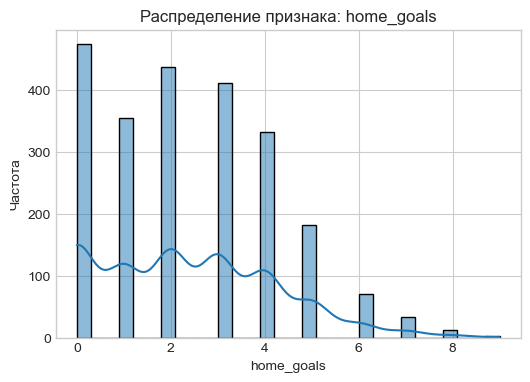

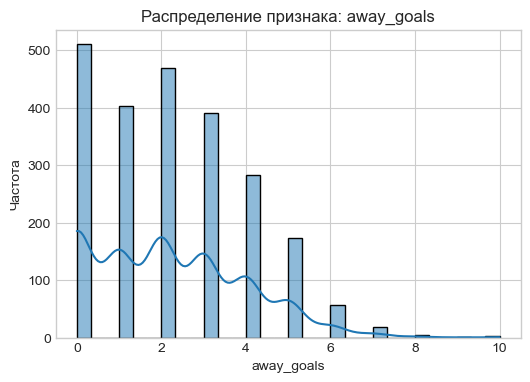

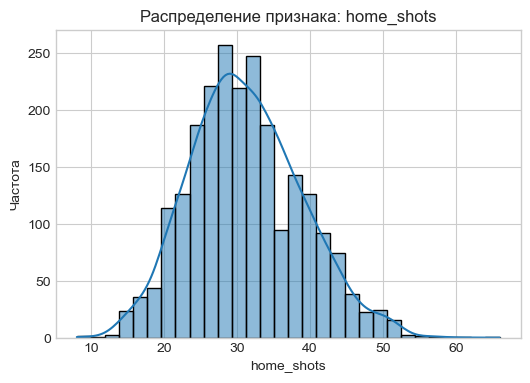

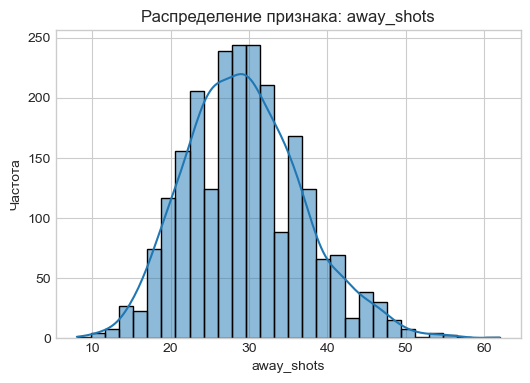

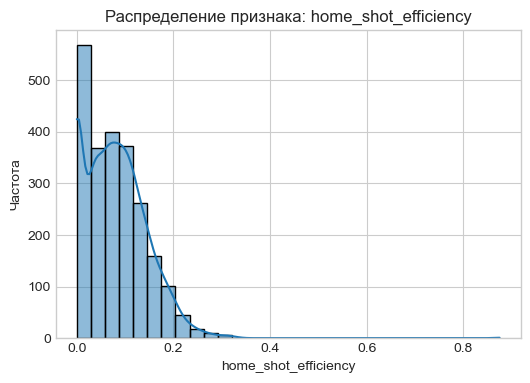

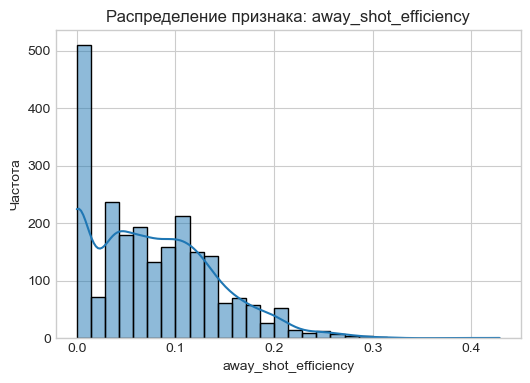

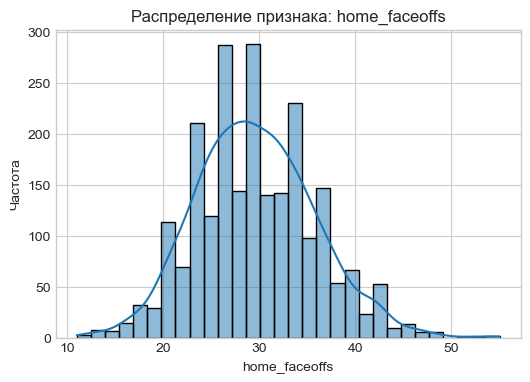

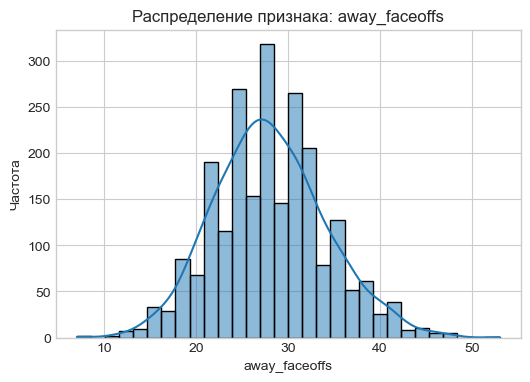

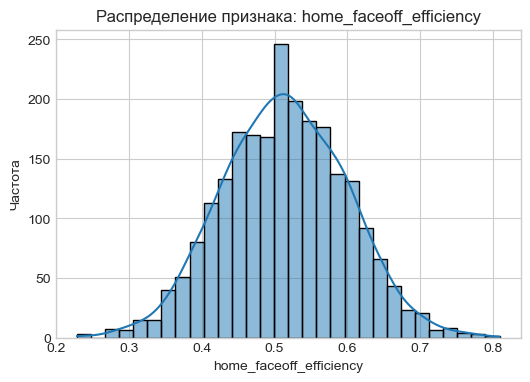

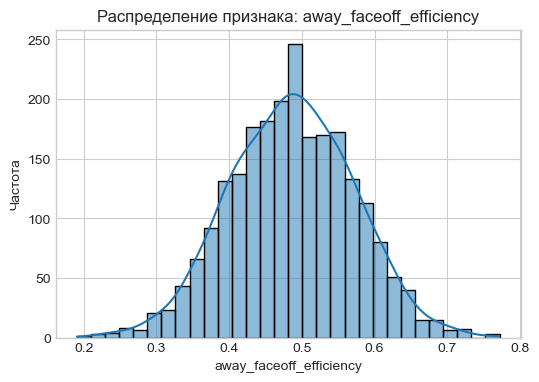

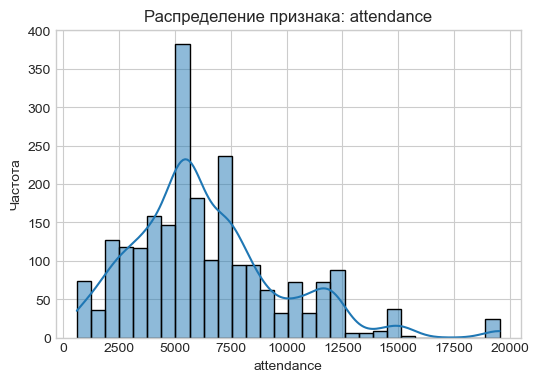

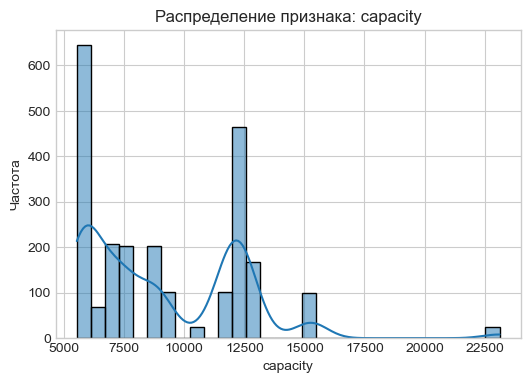

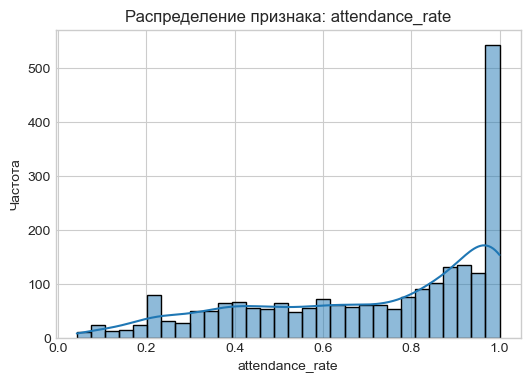

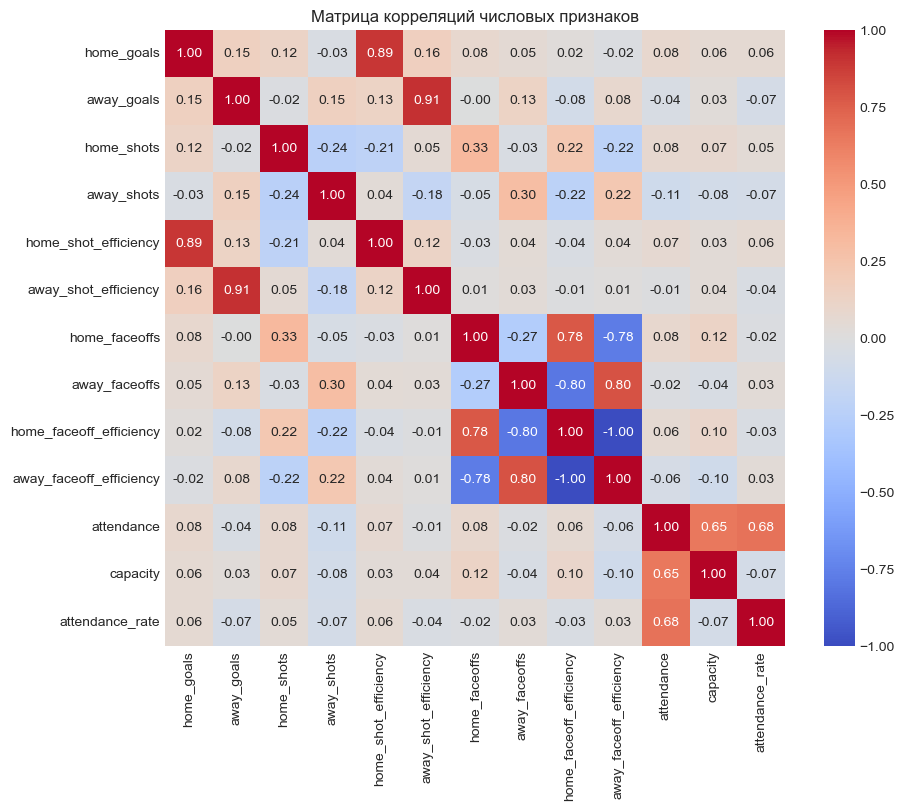

In [12]:
import matplotlib.pyplot as plt
import seaborn

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)
numeric_cols = [
    "home_goals", "away_goals",
    "home_shots", "away_shots",
    "home_shot_efficiency", "away_shot_efficiency",
    "home_faceoffs", "away_faceoffs",
    "home_faceoff_efficiency", "away_faceoff_efficiency",
    "attendance", "capacity", "attendance_rate"
]

for col in numeric_cols:
    plt.figure()
    seaborn.histplot(data[col], bins=30, kde=True)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.show()

corr = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
seaborn.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляций числовых признаков")
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "home_shots", "away_shots",
    "home_faceoffs", "away_faceoffs",
    "home_faceoff_efficiency", "away_faceoff_efficiency",
    "attendance", "capacity", "attendance_rate"
]

categorical_cols = ["home_team", "away_team"]
team_dummies = pandas.get_dummies(
    data[categorical_cols],
    prefix=["home", "away"],
    dtype=int
)

X_numeric = data[feature_cols].reset_index(drop=True)
X = pandas.concat([X_numeric, team_dummies.reset_index(drop=True)], axis=1)

print("Количество признаков после кодирования:", X.shape[1])
print("Форма X:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Количество признаков после кодирования: 55
Форма X: (2311, 55)


In [14]:
import numpy
from sklearn.metrics import silhouette_score

threshold = numpy.median(data["attendance_rate"])
print("Порог посещаемости для baseline:", threshold)

baseline_clusters = (data["attendance_rate"] >= threshold).astype(int)

print("Количество объектов первого кластера:", (baseline_clusters == 0).sum())
print("Количество объектов второго кластера:", (baseline_clusters == 1).sum())

baseline_silhouette = silhouette_score(X_scaled, baseline_clusters)
print("Silhouette baseline:", baseline_silhouette)



Порог посещаемости для baseline: 0.7974025974025974
Количество объектов первого кластера: 1155
Количество объектов второго кластера: 1156
Silhouette baseline: 0.03031230953422721


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

k_values = [2, 3, 4, 5, 6, 7, 8]
init_values = ["k-means++", "random"]

for k in k_values:
    for init_method in init_values:
        model = KMeans(
            n_clusters=k,
            init=init_method,
            n_init=10,
            random_state=42
        )

        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        results.append((k, init_method, sil))

print("Результаты подбора гиперпараметров:")
for k, init_method, sil in results:
    print(f"k={k}, init={init_method} → silhouette={sil:.4f}")

best_k, best_init, best_sil = max(results, key=lambda x: x[2])

print("Лучшие параметры:")
print(f"k={best_k}, init={best_init}, silhouette={best_sil:.4f}")



Результаты подбора гиперпараметров:
k=2, init=k-means++ → silhouette=0.0436
k=2, init=random → silhouette=0.0437
k=3, init=k-means++ → silhouette=0.0487
k=3, init=random → silhouette=0.0487
k=4, init=k-means++ → silhouette=0.0493
k=4, init=random → silhouette=0.0488
k=5, init=k-means++ → silhouette=0.0554
k=5, init=random → silhouette=0.0551
k=6, init=k-means++ → silhouette=0.0632
k=6, init=random → silhouette=0.0632
k=7, init=k-means++ → silhouette=0.0744
k=7, init=random → silhouette=0.0728
k=8, init=k-means++ → silhouette=0.0903
k=8, init=random → silhouette=0.0880
Лучшие параметры:
k=8, init=k-means++, silhouette=0.0903


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy

final_model = KMeans(
    n_clusters=best_k,
    init=best_init,
    n_init=10,
    random_state=42
)

final_labels = final_model.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, final_labels)

print("Финальная модель KMeans (sklearn)")
print("Число кластеров:", best_k)
print("Метод инициализации:", best_init)
print("Значение метрики silhouette:", final_silhouette)

unique, counts = numpy.unique(final_labels, return_counts=True)
print("Размеры кластеров:")
for label, count in zip(unique, counts):
    print(f"Кластер {label}: {count} объектов")

labels_sklearn = final_labels


Финальная модель KMeans (sklearn)
Число кластеров: 8
Метод инициализации: k-means++
Значение метрики silhouette: 0.09032902928420528
Размеры кластеров:
Кластер 0: 611 объектов
Кластер 1: 408 объектов
Кластер 2: 204 объектов
Кластер 3: 307 объектов
Кластер 4: 374 объектов
Кластер 5: 102 объектов
Кластер 6: 102 объектов
Кластер 7: 203 объектов


In [17]:
import numpy
from sklearn.metrics import silhouette_score

def kmeans_manual(X, n_clusters=8, max_iter=100, tol=1e-4, n_init=5, random_state=42):
    best_inertia = None
    best_labels = None
    best_centers = None

    for init_idx in range(n_init):
        numpy.random.seed(random_state + init_idx)
        indices = numpy.random.choice(len(X), n_clusters, replace=False)
        centers = X[indices]

        for i in range(max_iter):
            distances = numpy.linalg.norm(X[:, numpy.newaxis] - centers, axis=2)
            labels = numpy.argmin(distances, axis=1)

            new_centers = []
            for j in range(n_clusters):
                cluster_points = X[labels == j]
                if len(cluster_points) > 0:
                    new_centers.append(cluster_points.mean(axis=0))
                else:
                    new_centers.append(centers[j])

            new_centers = numpy.array(new_centers)

            if numpy.allclose(new_centers, centers, atol=tol):
                centers = new_centers
                break

            centers = new_centers

        inertia = numpy.sum((X - centers[labels]) ** 2)

        if best_inertia is None or inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels
            best_centers = centers

    return best_labels, best_centers

manual_results = []
manual_k_values = [k for k in [best_k - 1, best_k, best_k + 1] if k >= 2]
manual_n_init_values = [3, 5, 10]
manual_tol_values = [1e-3, 1e-4]

print("Подбор гиперпараметров для самописного KMeans")
for k in manual_k_values:
    for n_init in manual_n_init_values:
        for tol in manual_tol_values:
            labels, centers = kmeans_manual(
                X_scaled,
                n_clusters=k,
                max_iter=150,
                tol=tol,
                n_init=n_init,
                random_state=42
            )
            sil = silhouette_score(X_scaled, labels)
            manual_results.append((k, n_init, tol, sil))
            print(f"k={k}, n_init={n_init}, tol={tol} → silhouette={sil:.4f}")

manual_best_k, manual_best_n_init, manual_best_tol, manual_best_sil = max(manual_results, key=lambda x: x[3])

print("Лучшие параметры для самописного KMeans:")
print("k=", manual_best_k)
print("n_init=", manual_best_n_init)
print("tol=", manual_best_tol)
print("Silhouette=", manual_best_sil)

manual_labels, manual_centers = kmeans_manual(
    X_scaled,
    n_clusters=manual_best_k,
    max_iter=150,
    tol=manual_best_tol,
    n_init=manual_best_n_init,
    random_state=42
)

manual_silhouette = silhouette_score(X_scaled, manual_labels)

unique, counts = numpy.unique(manual_labels, return_counts=True)
print("Размеры кластеров для самописной модели:")
for label, count in zip(unique, counts):
    print(f"Кластер {label}: {count} объектов")


Подбор гиперпараметров для самописного KMeans
k=7, n_init=3, tol=0.001 → silhouette=0.0704
k=7, n_init=3, tol=0.0001 → silhouette=0.0704
k=7, n_init=5, tol=0.001 → silhouette=0.0707
k=7, n_init=5, tol=0.0001 → silhouette=0.0707
k=7, n_init=10, tol=0.001 → silhouette=0.0707
k=7, n_init=10, tol=0.0001 → silhouette=0.0707
k=8, n_init=3, tol=0.001 → silhouette=0.0829
k=8, n_init=3, tol=0.0001 → silhouette=0.0829
k=8, n_init=5, tol=0.001 → silhouette=0.0829
k=8, n_init=5, tol=0.0001 → silhouette=0.0829
k=8, n_init=10, tol=0.001 → silhouette=0.0863
k=8, n_init=10, tol=0.0001 → silhouette=0.0863
k=9, n_init=3, tol=0.001 → silhouette=0.1006
k=9, n_init=3, tol=0.0001 → silhouette=0.1006
k=9, n_init=5, tol=0.001 → silhouette=0.1006
k=9, n_init=5, tol=0.0001 → silhouette=0.1006
k=9, n_init=10, tol=0.001 → silhouette=0.0956
k=9, n_init=10, tol=0.0001 → silhouette=0.0956
Лучшие параметры для самописного KMeans:
k= 9
n_init= 3
tol= 0.001
Silhouette= 0.10057958449742695
Размеры кластеров для самописн

In [18]:
print("Сравнение моделей KMeans")

print("Silhouette (sklearn):", final_silhouette)
print("Silhouette (manual):", manual_silhouette)

difference = final_silhouette - manual_silhouette
print("Разница:", difference)


Сравнение моделей KMeans
Silhouette (sklearn): 0.09032902928420528
Silhouette (manual): 0.10057958449742695
Разница: -0.010250555213221671


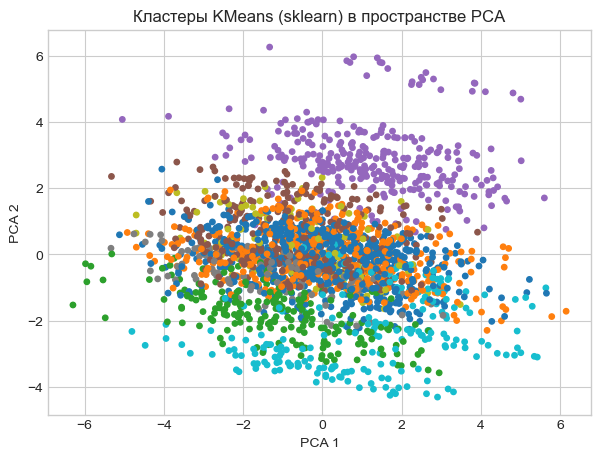

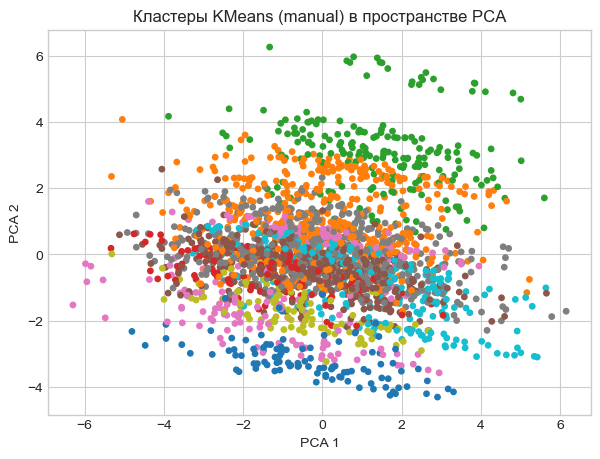

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=final_labels,
    cmap="tab10",
    s=15
)
plt.title("Кластеры KMeans (sklearn) в пространстве PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=manual_labels,
    cmap="tab10",
    s=15
)
plt.title("Кластеры KMeans (manual) в пространстве PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()
